# 01 - Initial EDA

Data: [Home Credit — Credit Risk Model Stability](https://www.kaggle.com/competitions/home-credit-credit-risk-model-stability) (Kaggle).

First pass over the data. Questions: how imbalanced is the target and does it drift over
time, how much of the static feature set is actually populated, which columns correlate with
default, and what the depth-1 tables (previous applications, credit bureau, cards, deposits)
look like. Some sanity checks at the end.


In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path

DATA = Path("../data/parquet_files")
TRAIN = DATA / "train"
TEST = DATA / "test"

pl.Config.set_tbl_rows(20)
plt.style.use("seaborn-v0_8-whitegrid")

base = pl.read_parquet(TRAIN / "train_base.parquet")
print(base.shape)
base.head()

(1526659, 5)


case_id,date_decision,MONTH,WEEK_NUM,target
i64,str,i64,i64,i64
0,"""2019-01-03""",201901,0,0
1,"""2019-01-03""",201901,0,0
2,"""2019-01-04""",201901,0,0
3,"""2019-01-03""",201901,0,0
4,"""2019-01-04""",201901,0,1


## Target distribution and temporal structure

shape: (2, 2)
┌────────┬─────────┐
│ target ┆ count   │
│ ---    ┆ ---     │
│ i64    ┆ u32     │
╞════════╪═════════╡
│ 0      ┆ 1478665 │
│ 1      ┆ 47994   │
└────────┴─────────┘

Default rate: 3.14%


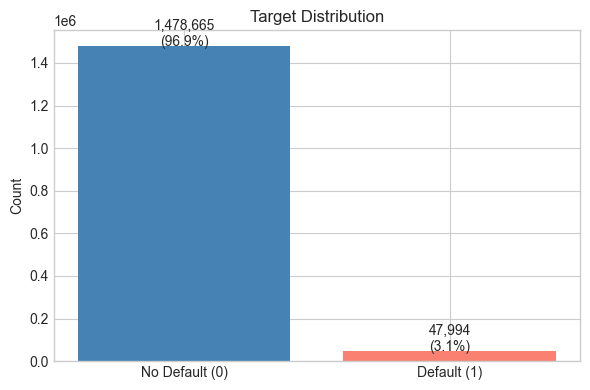

In [5]:
# Overall class balance
target_counts = base["target"].value_counts().sort("target")
print(target_counts)
print(f"\nDefault rate: {base['target'].mean():.2%}")

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["No Default (0)", "Default (1)"], 
       target_counts["count"].to_list(),
       color=["steelblue", "salmon"])
ax.set_title("Target Distribution")
ax.set_ylabel("Count")
for i, v in enumerate(target_counts["count"].to_list()):
    ax.text(i, v + 100, f"{v:,}\n({v/len(base):.1%})", ha="center")
plt.tight_layout()
plt.show()

WEEK_NUM range: 0 to 91
Total weeks: 92
Total cases: 1,526,659


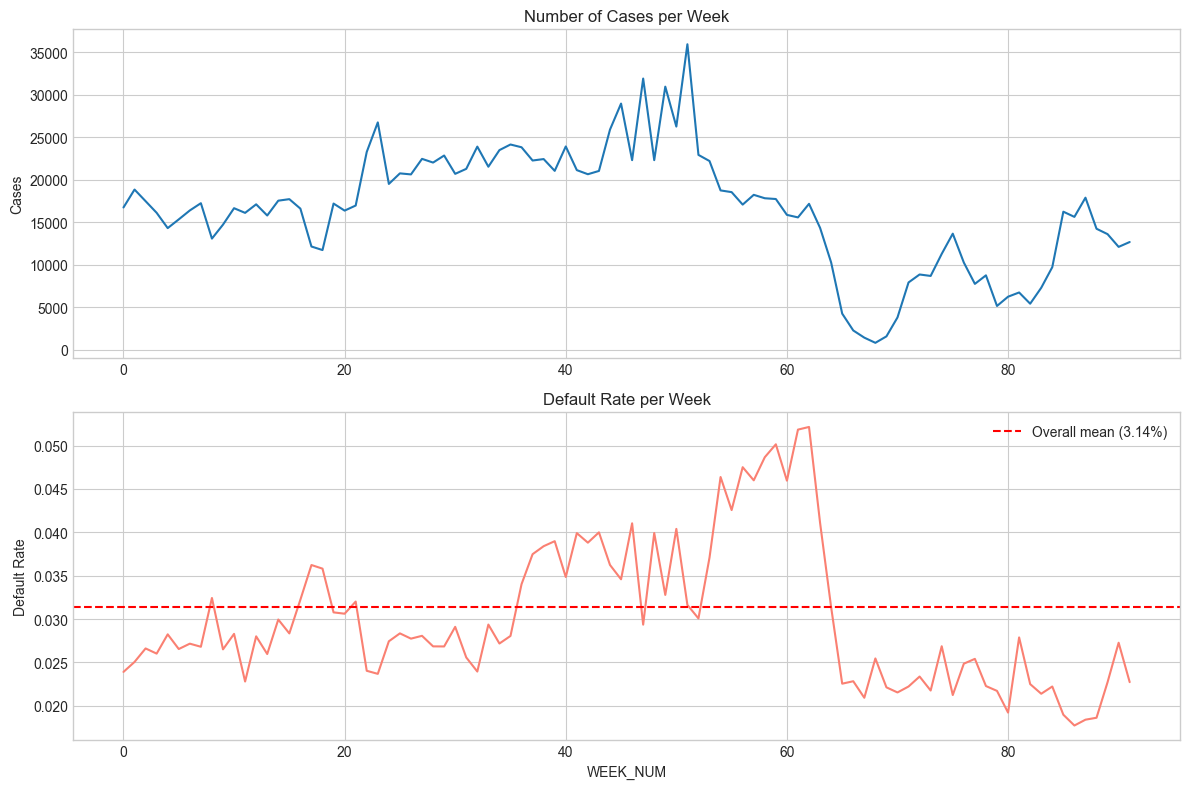

In [3]:
# How many weeks in train?
print(f"WEEK_NUM range: {base['WEEK_NUM'].min()} to {base['WEEK_NUM'].max()}")
print(f"Total weeks: {base['WEEK_NUM'].n_unique()}")
print(f"Total cases: {len(base):,}")

# Cases per week
weekly = (
    base.group_by("WEEK_NUM")
    .agg([
        pl.len().alias("n_cases"),
        pl.col("target").sum().alias("n_defaults"),
        pl.col("target").mean().alias("default_rate"),
    ])
    .sort("WEEK_NUM")
)

# Plot cases per week and default rate over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(weekly["WEEK_NUM"], weekly["n_cases"])
ax1.set_title("Number of Cases per Week")
ax1.set_ylabel("Cases")

ax2.plot(weekly["WEEK_NUM"], weekly["default_rate"], color="salmon")
ax2.axhline(base["target"].mean(), color="red", linestyle="--", 
            label=f"Overall mean ({base['target'].mean():.2%})")
ax2.set_title("Default Rate per Week")
ax2.set_ylabel("Default Rate")
ax2.set_xlabel("WEEK_NUM")
ax2.legend()

plt.tight_layout()
plt.show()

## Static application features: missingness and correlation with target

In [6]:
# Load static tables
static = pl.concat([
    pl.read_parquet(TRAIN / "train_static_0_0.parquet"),
    pl.read_parquet(TRAIN / "train_static_0_1.parquet"),
], how="vertical_relaxed")

print(f"Static shape: {static.shape}")
print(f"Columns: {static.width}")

# Join to base for correlation analysis
df = base.join(static, on="case_id", how="left")

Static shape: (1526659, 168)
Columns: 168


Top 20 most missing columns:
shape: (20, 3)
┌──────────────────────────────┬─────────┬───────────┐
│ variable                     ┆ value   ┆ null_rate │
│ ---                          ┆ ---     ┆ ---       │
│ str                          ┆ u32     ┆ f64       │
╞══════════════════════════════╪═════════╪═══════════╡
│ clientscnt_136L              ┆ 1526242 ┆ 0.999727  │
│ lastrepayingdate_696D        ┆ 1524282 ┆ 0.998443  │
│ lastotherinc_902A            ┆ 1523603 ┆ 0.997998  │
│ lastotherlnsexpense_631A     ┆ 1523601 ┆ 0.997997  │
│ payvacationpostpone_4187118D ┆ 1517330 ┆ 0.993889  │
│ isbidproductrequest_292L     ┆ 1514201 ┆ 0.99184   │
│ interestrategrace_34L        ┆ 1505776 ┆ 0.986321  │
│ lastdependentsnum_448L       ┆ 1497142 ┆ 0.980666  │
│ equalityempfrom_62L          ┆ 1488847 ┆ 0.975232  │
│ maxannuity_4075009A          ┆ 1450726 ┆ 0.950262  │
│ equalitydataagreement_891L   ┆ 1448632 ┆ 0.94889   │
│ datelastinstal40dpd_247D     ┆ 1392841 ┆ 0.912346  │
│ validfrom_1069D    

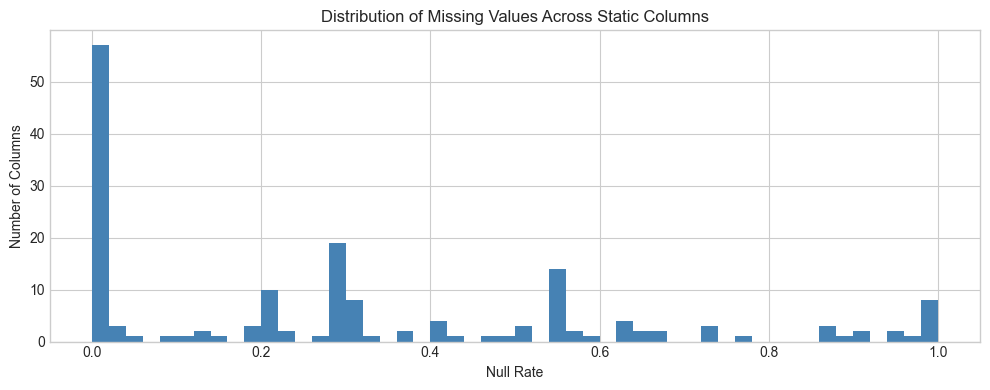

In [7]:
# What fraction of each column is null?
null_rates = (
    static.null_count()
    .unpivot()
    .with_columns((pl.col("value") / len(static)).alias("null_rate"))
    .sort("null_rate", descending=True)
)

print("Top 20 most missing columns:")
print(null_rates.head(20))

print(f"\nColumns >50% missing: {(null_rates['null_rate'] > 0.5).sum()}")
print(f"Columns >90% missing: {(null_rates['null_rate'] > 0.9).sum()}")

# Visual
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(null_rates["null_rate"].to_numpy(), bins=50, color="steelblue")
ax.set_xlabel("Null Rate")
ax.set_ylabel("Number of Columns")
ax.set_title("Distribution of Missing Values Across Static Columns")
plt.tight_layout()
plt.show()

In [11]:
# Polars native correlation - no pandas needed
target_corrs = []

numeric_cols = [c for c in df.columns if c.endswith(("A", "P"))]

for col in numeric_cols:
    try:
        corr = df.select(pl.corr(col, "target")).item()
        if corr is not None:
            target_corrs.append({"column": col, "correlation": abs(corr)})
    except:
        pass

corr_df = (
    pl.DataFrame(target_corrs)
    .sort("correlation", descending=True)
)

print("Top 20 features by absolute correlation with target:")
print(corr_df.head(20))

Top 20 features by absolute correlation with target:
shape: (20, 2)
┌────────────────────────────────┬─────────────┐
│ column                         ┆ correlation │
│ ---                            ┆ ---         │
│ str                            ┆ f64         │
╞════════════════════════════════╪═════════════╡
│ avgmaxdpdlast9m_3716943P       ┆ 0.089878    │
│ avgdbdtollast24m_4525197P      ┆ 0.056346    │
│ avgdbddpdlast24m_3658932P      ┆ 0.054034    │
│ avgdpdtolclosure24_3658938P    ┆ 0.052363    │
│ maxdpdtolerance_374P           ┆ 0.049517    │
│ mindbdtollast24m_4525191P      ┆ 0.049004    │
│ maxdbddpdtollast12m_3658940P   ┆ 0.047754    │
│ mindbddpdlast24m_3658935P      ┆ 0.047633    │
│ amtinstpaidbefduel24m_4187115A ┆ 0.045047    │
│ maxdpdfrom6mto36m_3546853P     ┆ 0.044739    │
│ maxdpdlast24m_143P             ┆ 0.042495    │
│ maxdbddpdtollast6m_4187119P    ┆ 0.042214    │
│ avgdbddpdlast3m_4187120P       ┆ 0.039799    │
│ maxdpdlast12m_727P             ┆ 0.038253    │
│

## Depth-1 tables: volume and coverage

In [12]:
tables_depth1 = {
    "applprev_1": pl.concat([
        pl.read_parquet(TRAIN / "train_applprev_1_0.parquet"),
        pl.read_parquet(TRAIN / "train_applprev_1_1.parquet"),
    ], how="vertical_relaxed"),
    "person_1": pl.read_parquet(TRAIN / "train_person_1.parquet"),
    "credit_bureau_b_1": pl.read_parquet(TRAIN / "train_credit_bureau_b_1.parquet"),
    "debitcard_1": pl.read_parquet(TRAIN / "train_debitcard_1.parquet"),
    "deposit_1": pl.read_parquet(TRAIN / "train_deposit_1.parquet"),
    "other_1": pl.read_parquet(TRAIN / "train_other_1.parquet"),
}

for name, df in tables_depth1.items():
    records_per_case = df.group_by("case_id").len()
    print(f"\n{name}:")
    print(f"  Total rows: {len(df):,}")
    print(f"  Unique case_ids: {df['case_id'].n_unique():,}")
    print(f"  Records per case_id - mean: {records_per_case['len'].mean():.1f}, "
          f"max: {records_per_case['len'].max()}, "
          f"median: {records_per_case['len'].median():.1f}")


applprev_1:
  Total rows: 6,525,979
  Unique case_ids: 1,221,522
  Records per case_id - mean: 5.3, max: 20, median: 4.0

person_1:
  Total rows: 2,973,991
  Unique case_ids: 1,526,659
  Records per case_id - mean: 1.9, max: 10, median: 1.0

credit_bureau_b_1:
  Total rows: 85,791
  Unique case_ids: 36,500
  Records per case_id - mean: 2.4, max: 21, median: 2.0

debitcard_1:
  Total rows: 157,302
  Unique case_ids: 111,772
  Records per case_id - mean: 1.4, max: 66, median: 1.0

deposit_1:
  Total rows: 145,086
  Unique case_ids: 105,111
  Records per case_id - mean: 1.4, max: 65, median: 1.0

other_1:
  Total rows: 51,109
  Unique case_ids: 51,109
  Records per case_id - mean: 1.0, max: 1, median: 1.0


In [13]:
base_ids = set(base["case_id"].to_list())

for name, df in tables_depth1.items():
    table_ids = set(df["case_id"].to_list())
    coverage = len(base_ids & table_ids) / len(base_ids)
    print(f"{name}: {coverage:.1%} of base cases have records")

applprev_1: 80.0% of base cases have records
person_1: 100.0% of base cases have records
credit_bureau_b_1: 2.4% of base cases have records
debitcard_1: 7.3% of base cases have records
deposit_1: 6.9% of base cases have records
other_1: 3.3% of base cases have records


## Key financial features

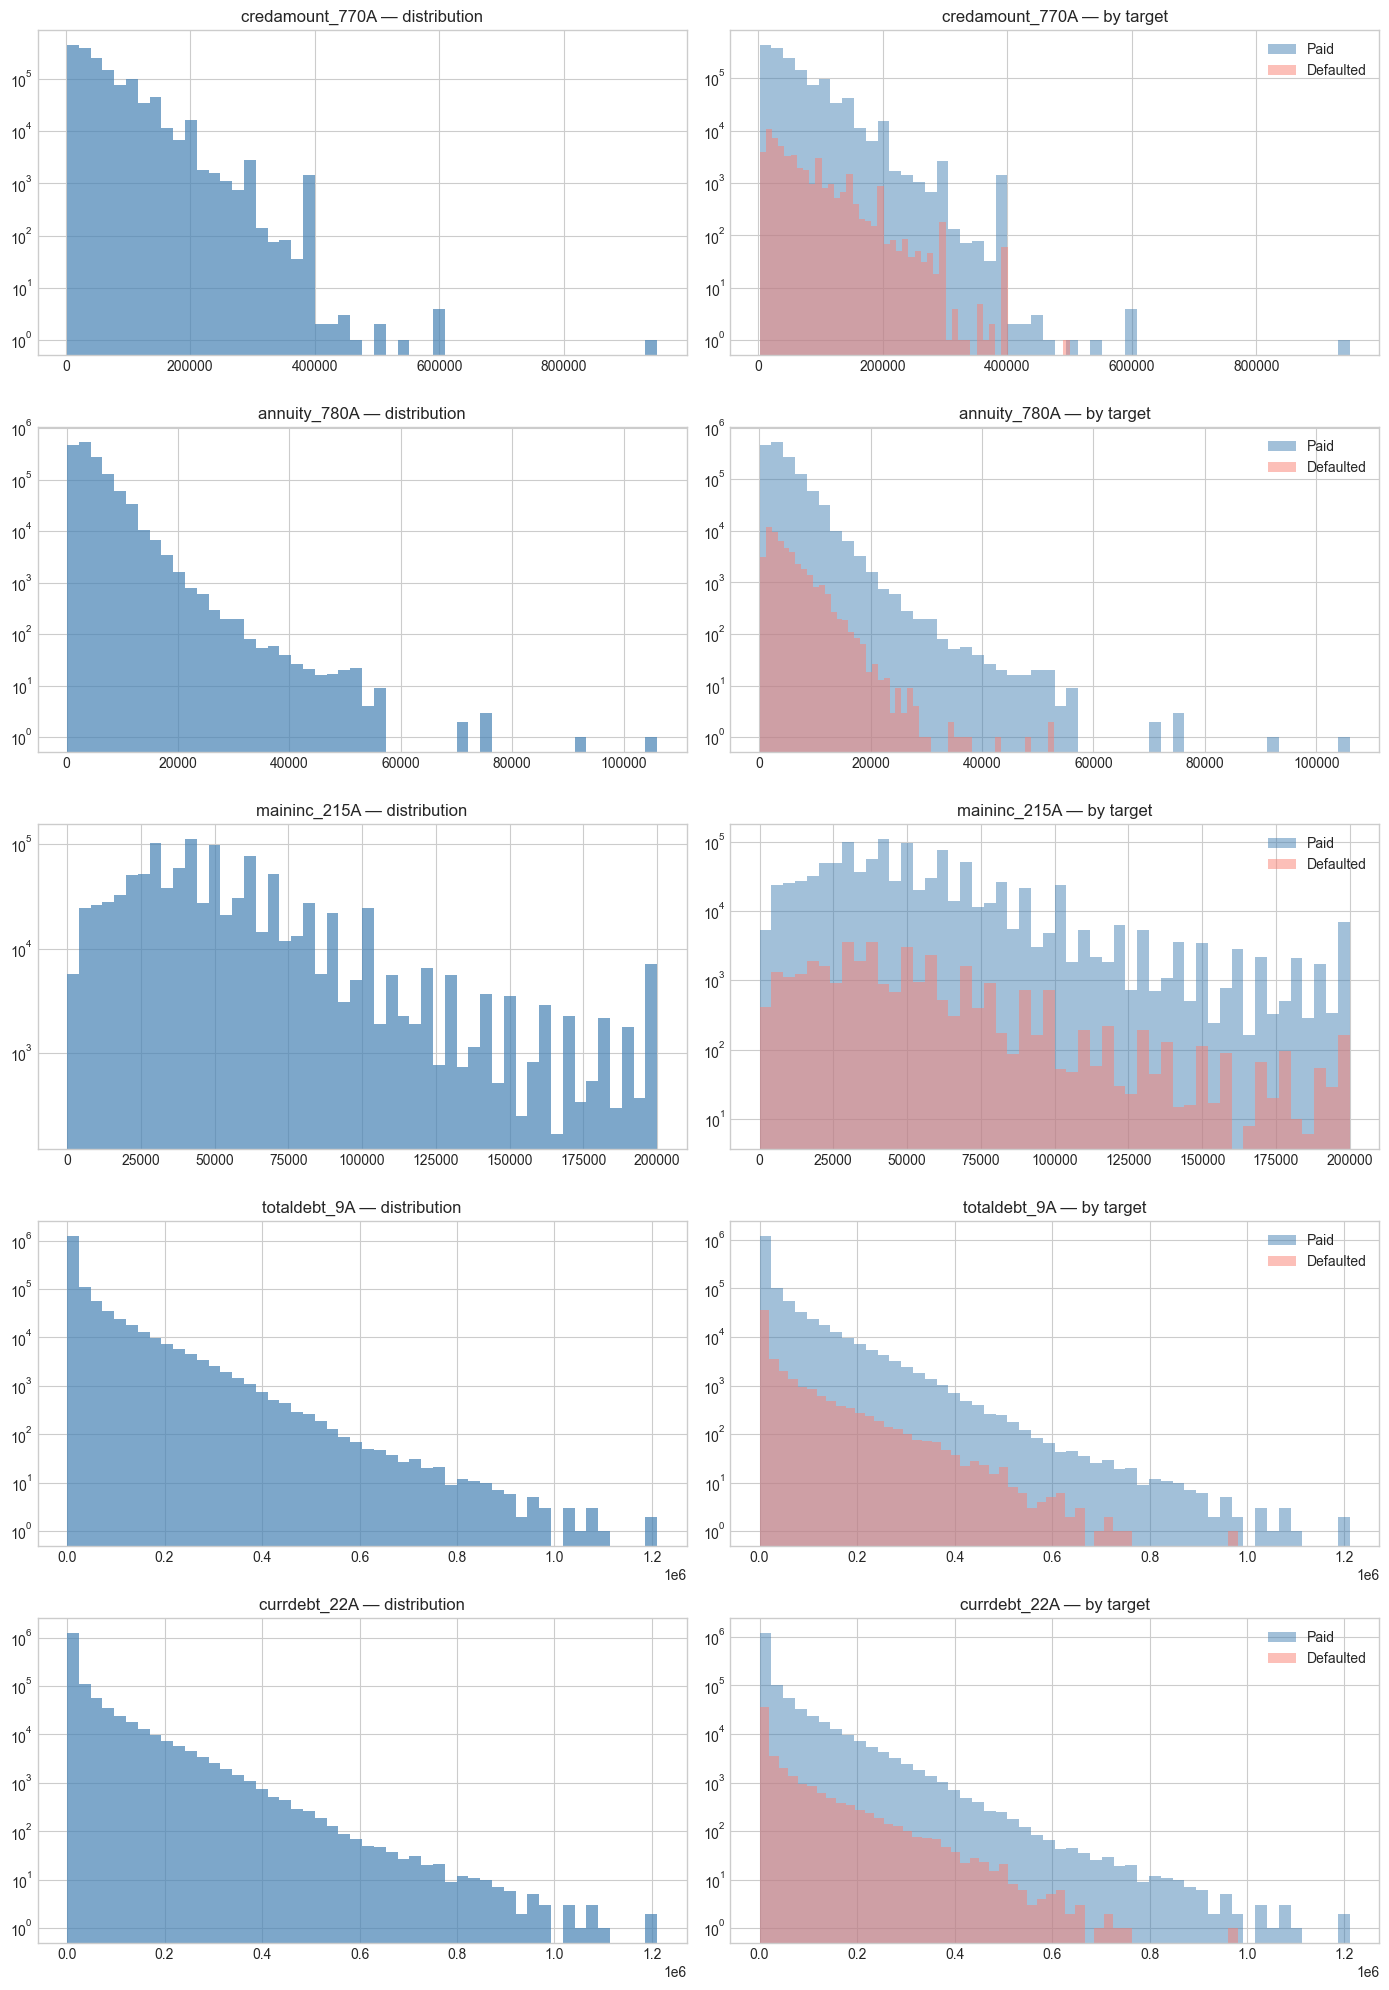

In [21]:
# Load joined data for this analysis
key_features = [
    "credamount_770A",       # loan amount
    "annuity_780A",          # monthly payment
    "maininc_215A",          # declared income  
    "totaldebt_9A",          # total debt
    "currdebt_22A",          # current debt
]

# For each: distribution, distribution by target, null rate
fig, axes = plt.subplots(len(key_features), 2, figsize=(14, 4*len(key_features)))

for i, col in enumerate(key_features):
    if col not in df.columns:
        continue
    
    col_data = df.select([col, "target"]).drop_nulls()
    
    # Overall distribution (log scale for amounts)
    axes[i, 0].hist(
        col_data[col].to_numpy(), 
        bins=50, color="steelblue", alpha=0.7
    )
    axes[i, 0].set_title(f"{col} — distribution")
    axes[i, 0].set_yscale("log")
    
    # By target
    defaulted = col_data.filter(pl.col("target") == 1)[col].to_numpy()
    paid = col_data.filter(pl.col("target") == 0)[col].to_numpy()
    axes[i, 1].hist(paid, bins=50, alpha=0.5, label="Paid", color="steelblue")
    axes[i, 1].hist(defaulted, bins=50, alpha=0.5, label="Defaulted", color="salmon")
    axes[i, 1].set_title(f"{col} — by target")
    axes[i, 1].set_yscale("log")
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

## Data quality checks

In [22]:
# Check for obviously wrong values
print("DAYS_BIRTH range (should be negative, days before application):")
if "days_birth" in [c.lower() for c in static.columns]:
    birth_col = [c for c in static.columns if "birth" in c.lower() and c.endswith("D")]
    for col in birth_col[:3]:
        print(f"  {col}: {static[col].min()} to {static[col].max()}")

# Check for infinite values in amount columns
amount_cols = [c for c in static.columns if c.endswith("A")][:10]
for col in amount_cols:
    try:
        vals = static[col].drop_nulls()
        if vals.dtype in (pl.Float32, pl.Float64):
            n_inf = vals.is_infinite().sum()
            if n_inf > 0:
                print(f"  {col}: {n_inf} infinite values")
    except:
        pass

# Duplicate case_ids in base (should be zero)
dupes = len(base) - base["case_id"].n_unique()
print(f"\nDuplicate case_ids in base: {dupes}")

# case_id coverage across static tables
static_ids = set(static["case_id"].to_list())
base_ids = set(base["case_id"].to_list())
missing_from_static = len(base_ids - static_ids)
print(f"Base case_ids missing from static: {missing_from_static}")

DAYS_BIRTH range (should be negative, days before application):

Duplicate case_ids in base: 0
Base case_ids missing from static: 0


## Days-past-due (DPD) features

The columns most correlated with default are all DPD features

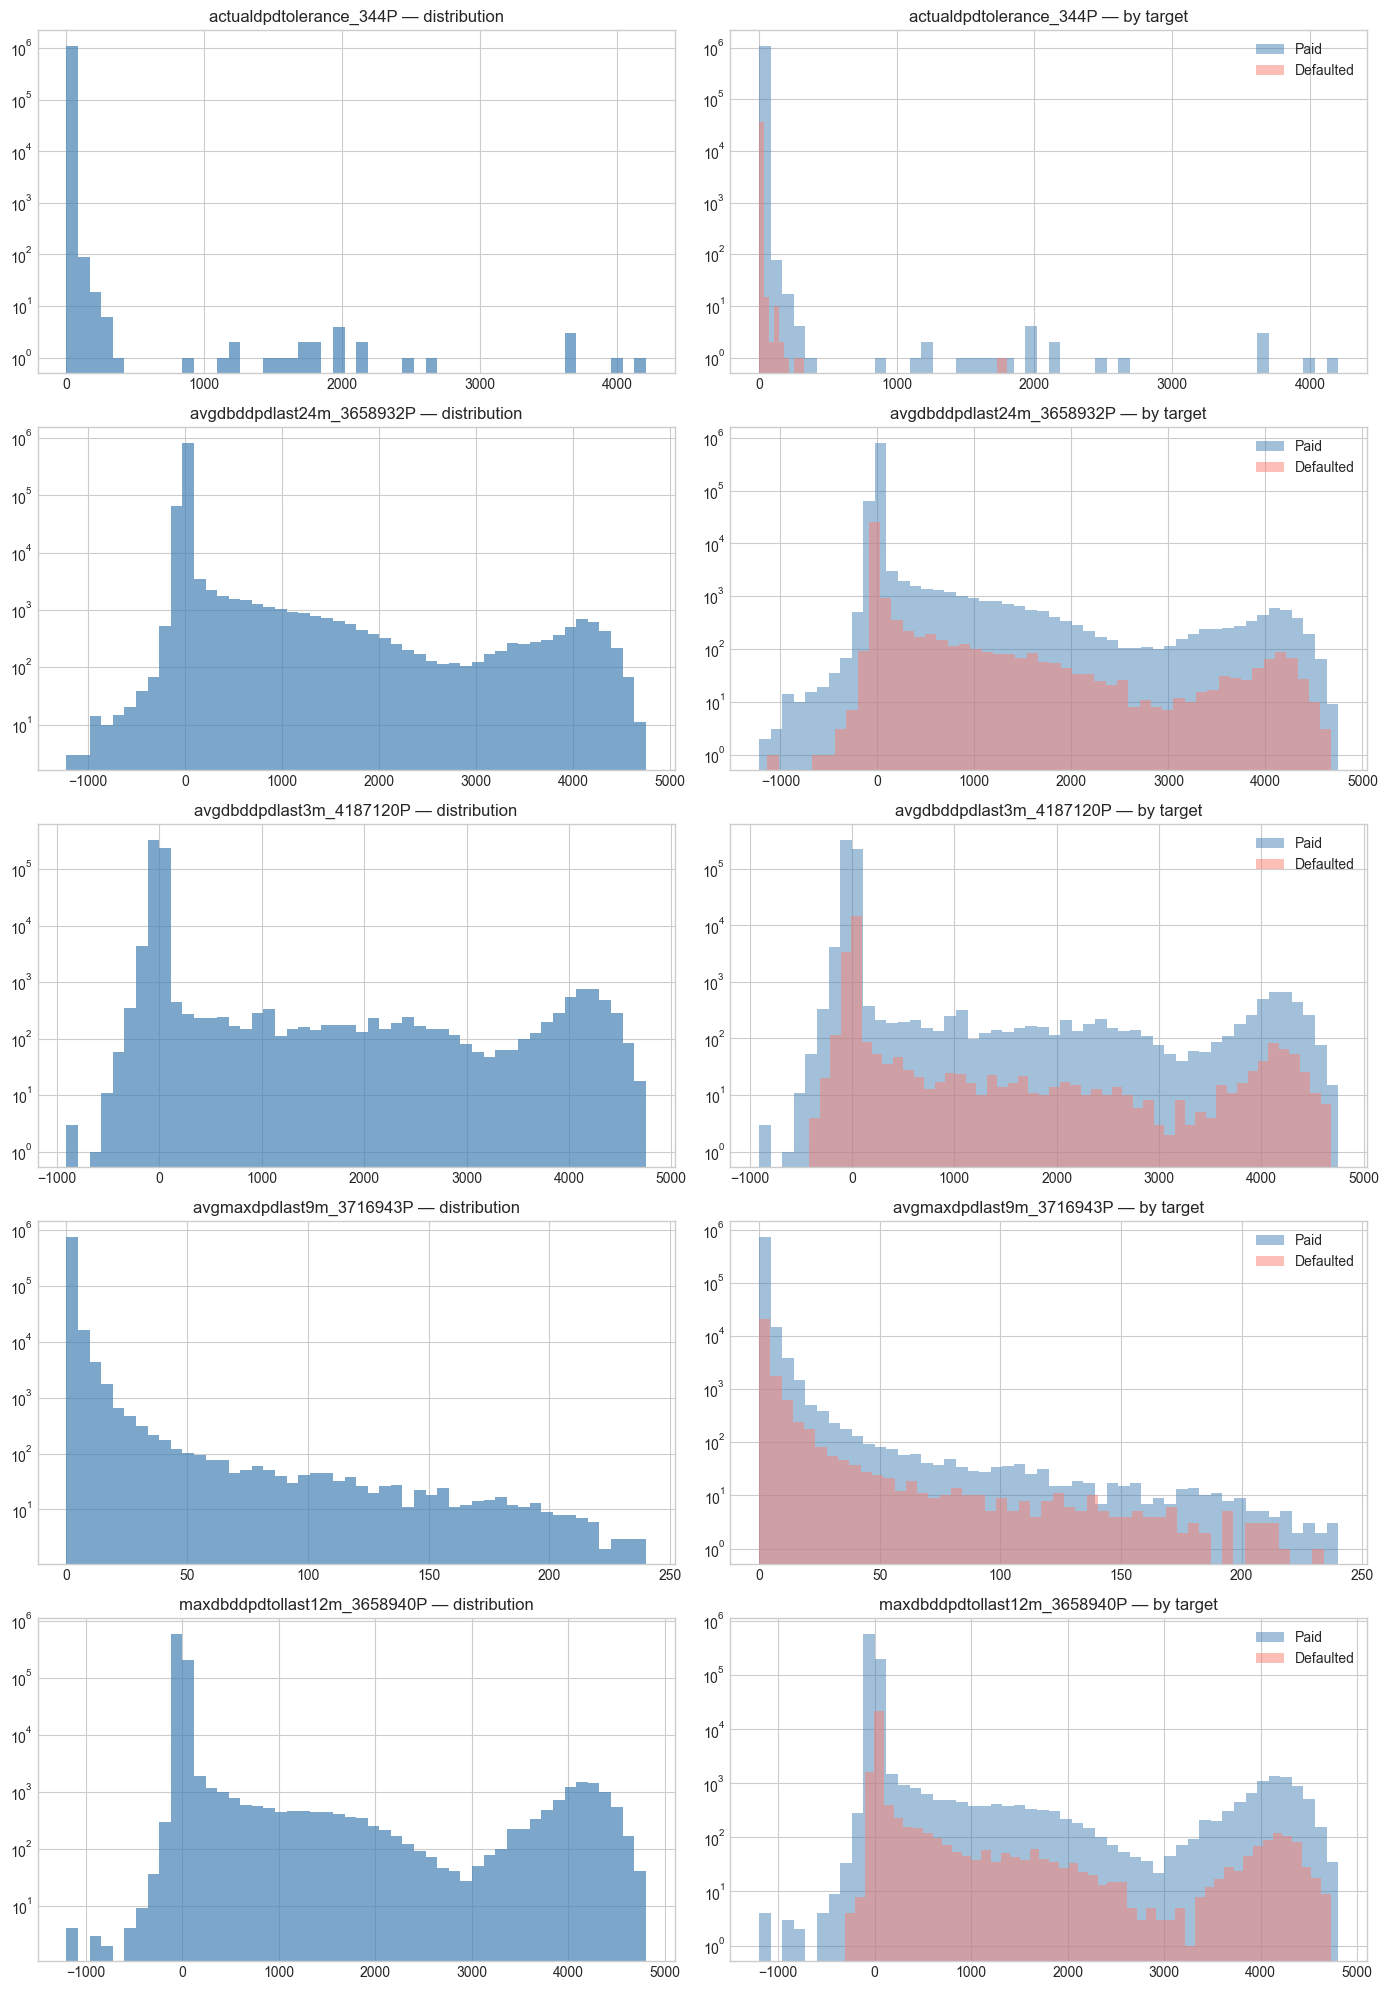

In [25]:
dpd_features = [
    "actualdpdtolerance_344P",
    "avgdbddpdlast24m_3658932P",
    "avgdbddpdlast3m_4187120P",
    "avgmaxdpdlast9m_3716943P",
    "maxdbddpdtollast12m_3658940P",
]

fig, axes = plt.subplots(len(dpd_features), 2, figsize=(14, 4*len(dpd_features)))

for i, col in enumerate(dpd_features):
    col_data = df.select([col, "target"]).drop_nulls()
    
    defaulted = col_data.filter(pl.col("target") == 1)[col].to_numpy()
    paid = col_data.filter(pl.col("target") == 0)[col].to_numpy()
    
    # Overall
    axes[i, 0].hist(col_data[col].to_numpy(), bins=50, 
                    color="steelblue", alpha=0.7)
    axes[i, 0].set_title(f"{col} — distribution")
    axes[i, 0].set_yscale("log")
    
    # By target
    axes[i, 1].hist(paid, bins=50, alpha=0.5, label="Paid", color="steelblue")
    axes[i, 1].hist(defaulted, bins=50, alpha=0.5, label="Defaulted", color="salmon")
    axes[i, 1].set_title(f"{col} — by target")
    axes[i, 1].set_yscale("log")
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

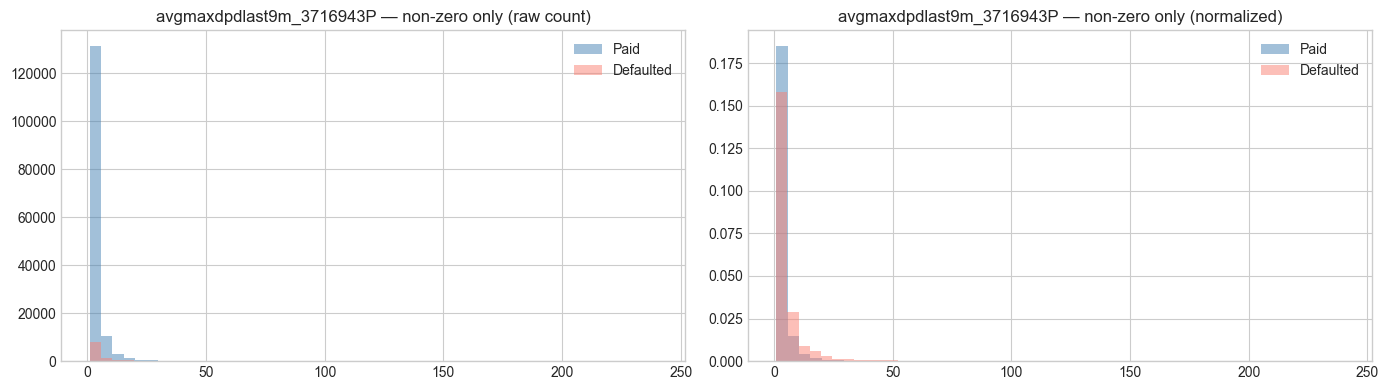

Default rate when DPD = 0: 2.15%
Default rate when DPD > 0: 6.67%


In [26]:
col = "avgmaxdpdlast9m_3716943P"

col_data = df.select([col, "target"]).drop_nulls()

# Remove zeros to see the tail distribution
nonzero = col_data.filter(pl.col(col) > 0)

defaulted = nonzero.filter(pl.col("target") == 1)[col].to_numpy()
paid = nonzero.filter(pl.col("target") == 0)[col].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(paid, bins=50, alpha=0.5, label="Paid", color="steelblue")
axes[0].hist(defaulted, bins=50, alpha=0.5, label="Defaulted", color="salmon")
axes[0].set_title(f"{col} — non-zero only (raw count)")
axes[0].legend()

# Normalize to show proportions not counts
axes[1].hist(paid, bins=50, alpha=0.5, label="Paid", color="steelblue", density=True)
axes[1].hist(defaulted, bins=50, alpha=0.5, label="Defaulted", color="salmon", density=True)
axes[1].set_title(f"{col} — non-zero only (normalized)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Also print default rate at zero vs non-zero
zero_default = col_data.filter(pl.col(col) == 0)["target"].mean()
nonzero_default = col_data.filter(pl.col(col) > 0)["target"].mean()
print(f"Default rate when DPD = 0: {zero_default:.2%}")
print(f"Default rate when DPD > 0: {nonzero_default:.2%}")